## Quantstats

In [44]:
import numpy as np
import pandas as pd
%matplotlib inline
import quantstats as qs
file_name = "quantstats_report.html"

# fetch the daily returns for a stock
# stock = qs.utils.download_returns('FB')

# show sharpe ratio
# qs.stats.sharpe(stock)

# qs.plots.snapshot(stock, title='Facebook Performance')

# qs.reports.metrics(stock, "SPY", mode="full", compounded=False)
# qs.reports.metrics(stock, "SPY", mode="full")
# qs.reports.plots(stock, "SPY", mode="full")
# qs.reports.html(stock, "SPY", output=file_name)

In [77]:
from dateutil import parser
res = {}
for line in open("../../front/stats.csv", "r"):
    if "date" not in line:
        stats = line.strip().split(",")
        dt, val = stats[0], stats[1]
        res[parser.parse(dt)] = float(val)
stock = pd.Series(res)
stock.index.tz_localize("UTC")

stock = stock.resample("1D").pad()

# pd.DataFrame(stock.tail(50))

md = pd.DataFrame(stock).copy(deep=True)
md["delta_1"] = pd.DataFrame(stock).rolling(window=10).apply(lambda x: x.iloc[-1] - x.iloc[0])
md["delta_2"] = pd.DataFrame(stock).rolling(window=30).apply(lambda x: x.iloc[-1] - x.iloc[0])


import plotly.graph_objects as go
import plotly.subplots as sub
import quantstats as qs
from jup.helpers.charts import (
    get_layout,
    get_price_trace,
    add_trade_markers,
    remove_x_gaps,
    detect_range_rule,
)
from jup.helpers.data_sources import get_exante_data, resample_ohlc

layout = get_layout()

fig = sub.make_subplots(
    figure=go.Figure(layout=layout),
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.02,
    row_heights=[0.6, 0.2, 0.2],
)

line = dict(color="rgba(0,0,0,0.5)", width=1)
fig.add_trace(go.Scatter(x=md.index, y=md[0], line=line, name="close"))

color = np.where((md["delta_1"] < 0), 'red', '#0b0')
fig.add_trace(go.Bar(x=md.index, y=abs(md["delta_1"]), marker_color=color), row=2, col=1)

color = np.where((md["delta_2"] < 0), 'red', '#0b0')
fig.add_trace(go.Bar(x=md.index, y=abs(md["delta_2"]), marker_color=color), row=3, col=1)


# stock.tail(50).plot.bar(rot=0)

                           Strategy
-------------------------  ----------
Start Period               2019-01-02
End Period                 2021-09-03
Risk-Free Rate             0.0%
Time in Market             98.0%

Cumulative Return          185.68%
CAGR%                      48.14%

Sharpe                     0.94
Sortino                    1.67
Sortino/√2                 1.18

Max Drawdown               -11.33%
Longest DD Days            194
Volatility (ann.)          5.7%
Calmar                     4.25
Skew                       4.7
Kurtosis                   96.93

Expected Daily %           0.02%
Expected Monthly %         3.23%
Expected Yearly %          41.89%
Kelly Criterion            11.2%
Risk of Ruin               0.0%
Daily Value-at-Risk        -0.57%
Expected Shortfall (cVaR)  -0.57%

Gain/Pain Ratio            0.65
Gain/Pain (1M)             7.14

Payoff Ratio               1.19
Profit Factor              1.28
Common Sense Ratio         1.51
CPC Index                  

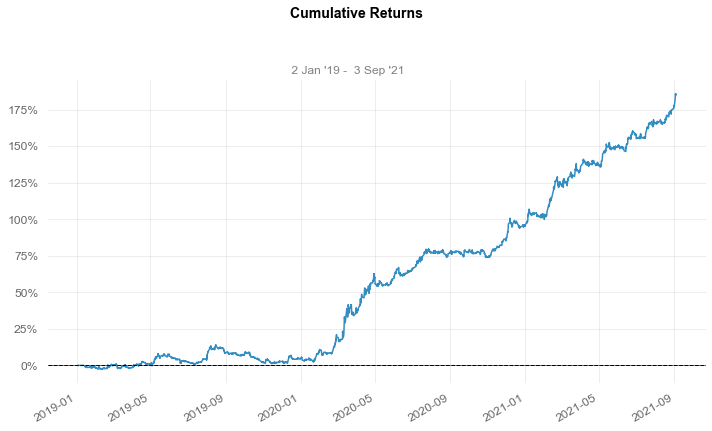

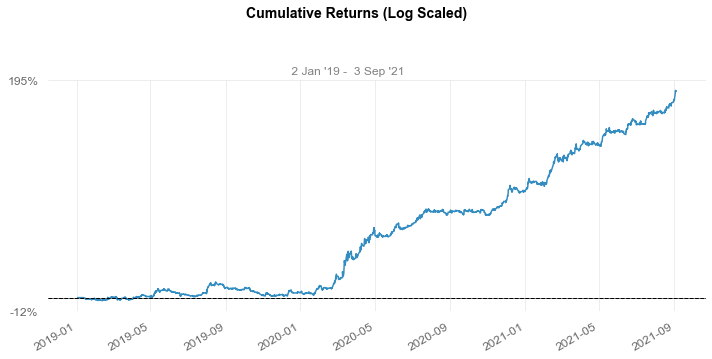

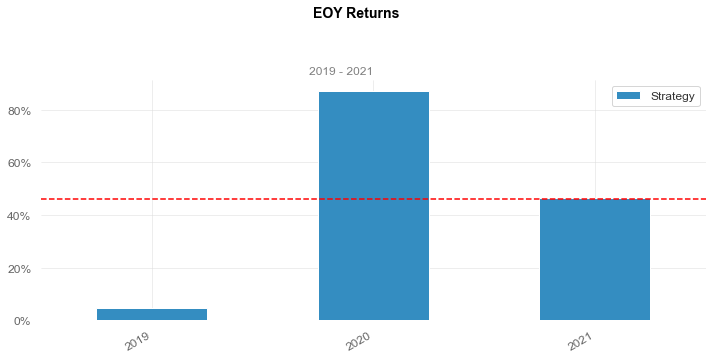

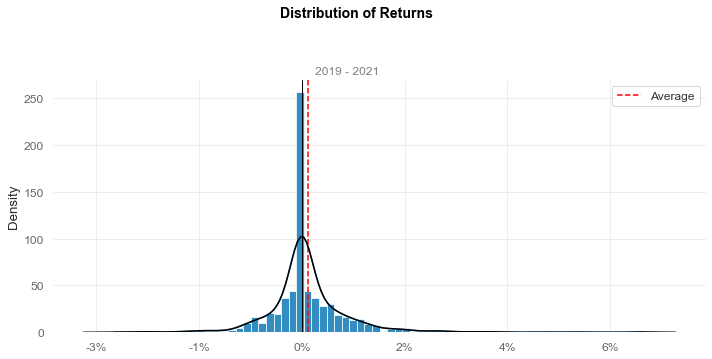

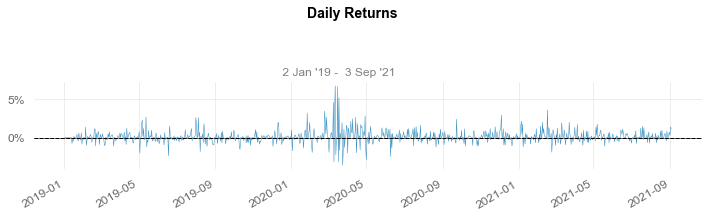

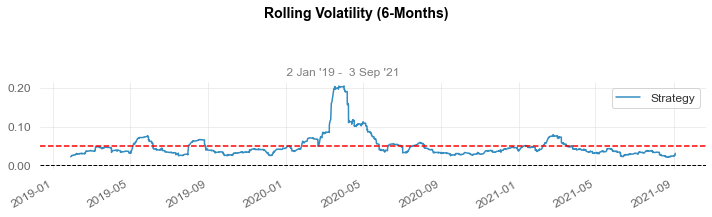

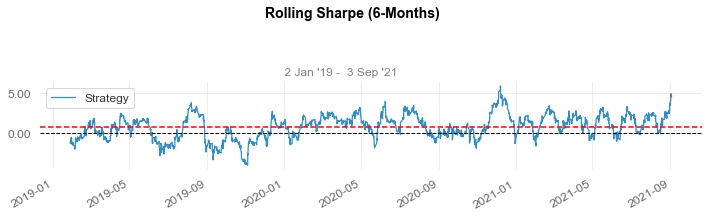

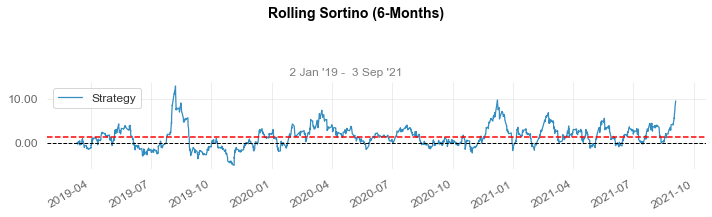

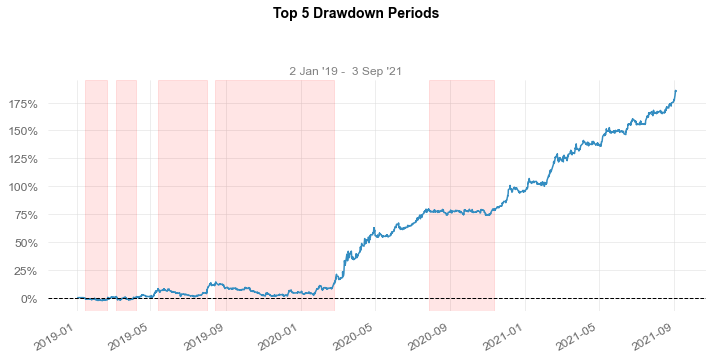

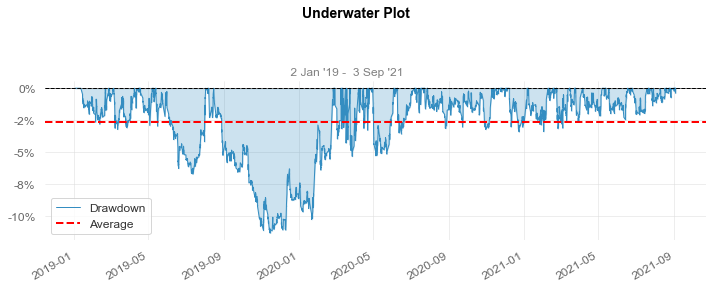

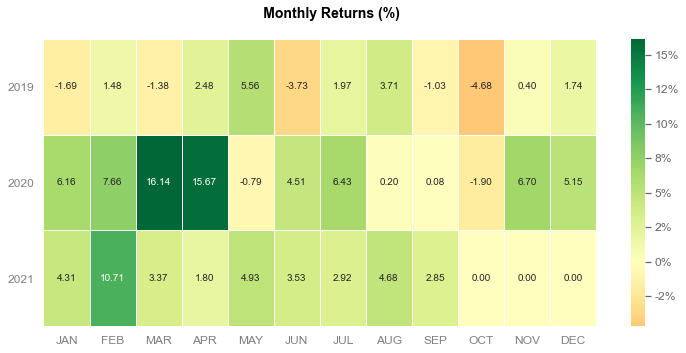

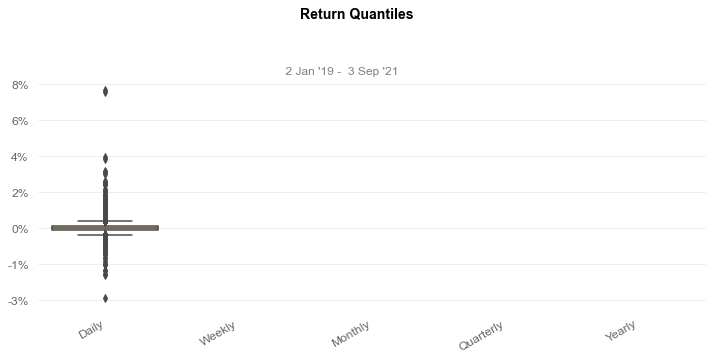

In [17]:
qs.reports.metrics(stock, mode="full", compounded=True)
qs.reports.plots(stock, mode="full", figsize=(10, 5))

In [18]:
qs.reports.html(stock, output=file_name)

import webbrowser, os
_ = webbrowser.open('file:///' + os.path.realpath(file_name))
